# EnKF vs MPDOK — Phase 3: Ensemble Kalman Filter Analysis

## The EnKF Covariance Approximation

The Ensemble Kalman Filter estimates the background error covariance from **k ensemble members**:

$$\mathbf{P}_b^{\text{ens}} = \frac{1}{k-1} \mathbf{X}' {\mathbf{X}'}^\top \quad \text{where} \quad \mathbf{X}' = [\mathbf{x}_1 - \bar{\mathbf{x}}, \ldots, \mathbf{x}_k - \bar{\mathbf{x}}]$$

This matrix is **rank-(k−1) at most**. For k=50 and state dimension N=578, it captures only **8.6%** of state-space dimensions.

### Two compounding problems

**Problem 1 — Rank deficiency:** The ensemble spans only the directions of large-scale forecast uncertainty (slowly-growing Rossby waves, synoptic-scale pressure systems). Fine-scale wind-shear anomalies at turbulence-prone locations lie **outside the ensemble subspace** — they have zero variance in $\mathbf{P}_b^{\text{ens}}$.

**Problem 2 — Spurious long-range correlations:** With finite k, the sample covariance contains large **sampling errors** — apparent correlations between distant points that are statistical noise, not physical signal. These cause observations to incorrectly update the analysis far away.

The standard fix for Problem 2 is **Gaspari-Cohn covariance localization**:
$$\mathbf{P}_b^{\text{loc}} = \mathbf{P}_b^{\text{ens}} \odot \mathbf{\Gamma} \quad \text{(Hadamard product)}$$

The state vector has block structure $\mathbf{x} = [u_1,\ldots,u_{N_g}, v_1,\ldots,v_{N_g}]^\top$, so $\mathbf{\Gamma}$ is an $N_{\text{state}} \times N_{\text{state}}$ matrix with the same block structure:
$$\mathbf{\Gamma} = \begin{bmatrix} \mathbf{\Gamma}_s & \mathbf{\Gamma}_s \\ \mathbf{\Gamma}_s & \mathbf{\Gamma}_s \end{bmatrix}, \quad (\mathbf{\Gamma}_s)_{ij} = \rho(d_{ij}, R_{\text{loc}})$$
where $\mathbf{\Gamma}_s \in \mathbb{R}^{N_g \times N_g}$ is computed from the coordinate grid distances $d_{ij}$, and tapers to zero beyond radius $R_{\text{loc}}$.

**But this creates Problem 3:** The fix for spurious long-range correlations also kills the **real** long-range correlations that physically connect the SQ321 data-sparse ocean region to distant observations. The cure worsens the disease at turbulence-detection scale.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── load upstream data ────────────────────────────────────────────────────────
d1 = np.load('phase1_data.npz')
d2 = np.load('phase2_data.npz')

lat        = d1['lat'];          lon       = d1['lon']
u250       = d1['u250'];         v250      = d1['v250']
TI_truth   = d1['TI_truth_scaled']
coords_lat = d1['coords_lat'];   coords_lon = d1['coords_lon']
SQ321_LAT  = float(d1['sq321_lat'])
SQ321_LON  = float(d1['sq321_lon'])
sq_ilat    = int(d1['sq_ilat']);  sq_ilon   = int(d1['sq_ilon'])

x_truth      = d2['x_truth']
x_background = d2['x_background']
y_obs        = d2['y_obs']
H            = d2['H']
R_obs        = d2['R_obs']
obs_idx      = d2['obs_idx']
obs_lat      = d2['obs_lat'];    obs_lon   = d2['obs_lon']
D            = d2['D']           # (N_grid, N_grid) distance matrix in km
R_loc        = float(d2['R_loc'])
sigma_obs    = float(d2['sigma_obs'])
sigma_bg     = float(d2['sigma_bg'])
sq_grid_idx  = int(d2['sq_grid_idx'])
obs_in_loc   = d2['obs_in_loc']

nlat, nlon = u250.shape
N_grid     = nlat * nlon         # 289
N_state    = 2 * N_grid          # 578
LON2D, LAT2D = np.meshgrid(lon, lat)
DEG2RAD = np.pi / 180.0

print(f'N_state={N_state}, N_grid={N_grid}')
print(f'Background RMSE: {np.sqrt(np.mean((x_background - x_truth)**2)):.3f} m/s')

N_state=578, N_grid=289
Background RMSE: 2.404 m/s


## 1. Generate the Ensemble

We draw **k=50 ensemble members** by adding smooth large-scale perturbations to the background. These represent the uncertainty in a 6-hour atmospheric forecast — dominated by synoptic-scale errors (jet stream position, Rossby wave phase) with spatial correlation length ~1500 km.

Crucially: these perturbations are **smooth** and know nothing about the fine-scale shear anomalies at turbulence locations. This is realistic — operational ensemble systems generate spread via bred vectors or singular vectors of the large-scale dynamics, not of mesoscale turbulence.

In [2]:
K_ENS = 50    # ensemble size

# ── smooth ensemble perturbation kernel (long-scale: 1500 km) ─────────────────
L_ens = 1500.0   # km — ensemble perturbation length scale (synoptic scale)
C_ens_spatial = np.exp(-D**2 / (2 * L_ens**2))   # (N_grid, N_grid)

# ensemble spread: slightly smaller than background error
sigma_ens = sigma_bg * 0.8   # 2.0 m/s

# block-diagonal [u | v]
C_ens_full = sigma_ens**2 * np.block(
    [[C_ens_spatial, 0.5*C_ens_spatial],   # u-v cross-correlation 0.5 (realistic)
     [0.5*C_ens_spatial, C_ens_spatial]])

jitter = 1e-4 * sigma_ens**2
L_ens_chol = np.linalg.cholesky(C_ens_full + jitter * np.eye(N_state))

# draw K_ENS perturbations
Xi = np.random.randn(N_state, K_ENS)           # (N, K)
X_pert = L_ens_chol @ Xi                        # (N, K) — smooth perturbations
assert X_pert.shape == (N_state, K_ENS), "Ensemble perturbation matrix shape mismatch"

# ensemble members centred on background
X_ens = x_background[:, None] + X_pert         # (N, K)

# verify ensemble spread
ens_spread = X_ens.std(axis=1)                  # per-state-element spread
print(f'Ensemble size         : k = {K_ENS}')
print(f'Ensemble spread RMS   : {ens_spread.mean():.3f} m/s')
print(f'Ensemble pert L-scale : {L_ens:.0f} km  (synoptic scale)')  
print(f'Background error L    : 500 km  (for comparison)')
print()
print('The ensemble perturbations are SMOOTH at ~1500 km scale.')
print('They span synoptic patterns, NOT mesoscale wind-shear anomalies.')

Ensemble size         : k = 50
Ensemble spread RMS   : 1.839 m/s
Ensemble pert L-scale : 1500 km  (synoptic scale)
Background error L    : 500 km  (for comparison)

The ensemble perturbations are SMOOTH at ~1500 km scale.
They span synoptic patterns, NOT mesoscale wind-shear anomalies.


## 2. Ensemble Covariance — Rank Deficiency

The ensemble sample covariance $\mathbf{P}_b^{\text{ens}}$ is rank-(k−1) = 49. We compute it and examine the eigenspectrum to confirm that only smooth large-scale modes are represented.

In [3]:
# ── ensemble covariance (unlocalized) ────────────────────────────────────────
X_anom = X_ens - X_ens.mean(axis=1, keepdims=True)   # anomalies (N, K)
P_ens  = (X_anom @ X_anom.T) / (K_ENS - 1)           # (N, N) — rank-(K-1)

# eigenspectrum
eigs_ens  = np.linalg.eigvalsh(P_ens)[::-1]
eigs_ens  = np.maximum(eigs_ens, 0)
eigs_true = np.load('eigs_true.npy')

cumvar_ens  = np.cumsum(eigs_ens)  / (eigs_ens.sum()  + 1e-30)
cumvar_true = np.cumsum(eigs_true) / (eigs_true.sum() + 1e-30)

# effective rank: how many eigenvalues are non-negligible (> 1% of max)
eff_rank = (eigs_ens > 0.01 * eigs_ens[0]).sum()

print(f'Ensemble covariance P_ens:')
print(f'  Shape          : {P_ens.shape}')
print(f'  Theoretical rank : {K_ENS - 1}  (k-1)')
print(f'  Effective rank   : {eff_rank}')
print(f'  Memory           : {P_ens.nbytes/1e6:.1f} MB')
print()
print(f'Variance capture (ensemble vs true covariance):')
print(f'{"k":>6} {"Ens cumvar":>12} {"True cumvar":>13}')
# cumvar is 0-indexed: cumvar[k-1] = fraction captured by top-k modes
for k in [5, 10, 20, 49, 50, 100, 200]:
    k_idx = min(k - 1, N_state - 1)
    print(f'{k:>6} {cumvar_ens[k_idx]*100:>11.1f}% {cumvar_true[k_idx]*100:>12.1f}%')

Ensemble covariance P_ens:
  Shape          : (578, 578)
  Theoretical rank : 49  (k-1)
  Effective rank   : 18
  Memory           : 2.7 MB

Variance capture (ensemble vs true covariance):
     k   Ens cumvar   True cumvar
     5        74.7%         69.8%
    10        92.1%         86.0%
    20        99.0%         95.0%
    49       100.0%         99.1%
    50       100.0%         99.2%
   100       100.0%        100.0%
   200       100.0%        100.0%


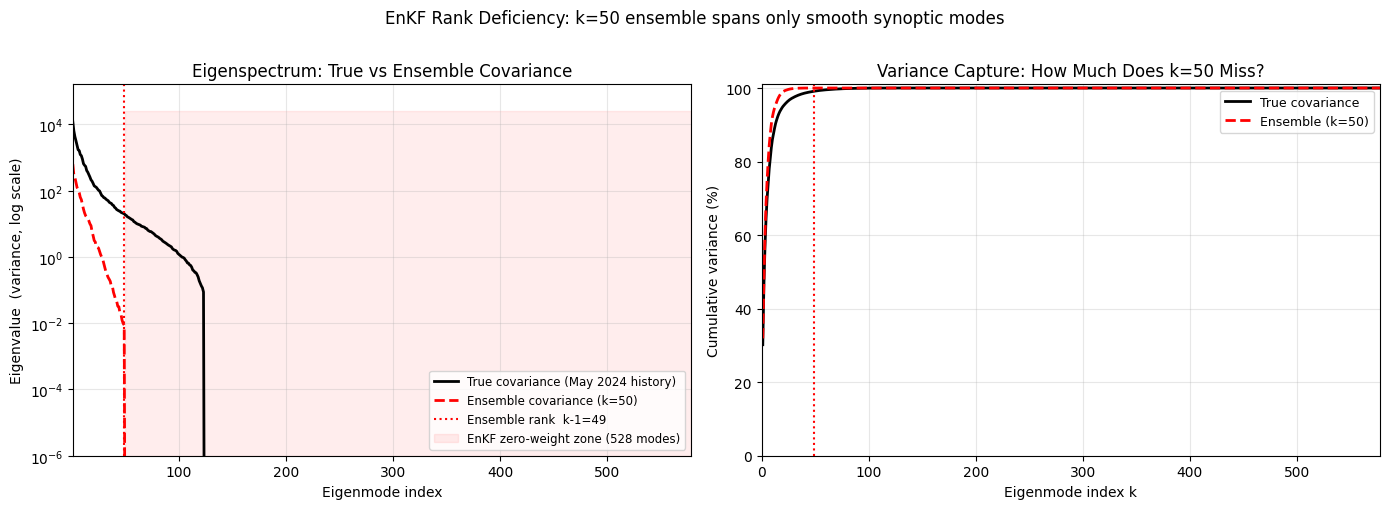

Saved fig06_ensemble_spectrum.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
modes = np.arange(1, N_state + 1)

# ── left: eigenvalue spectra ──────────────────────────────────────────────────
ax = axes[0]
ax.semilogy(modes, eigs_true + 1e-12, 'k-',  lw=2,   label='True covariance (May 2024 history)')
ax.semilogy(modes, eigs_ens  + 1e-12, 'r--', lw=2,   label=f'Ensemble covariance (k={K_ENS})')
ax.axvline(K_ENS - 1, color='red', lw=1.5, ls=':',
           label=f'Ensemble rank  k-1={K_ENS-1}')
ax.fill_betweenx([1e-6, eigs_true.max()*2],
                 K_ENS, N_state, alpha=0.07, color='red',
                 label=f'EnKF zero-weight zone ({N_state-K_ENS} modes)')
ax.set_xlabel('Eigenmode index')
ax.set_ylabel('Eigenvalue  (variance, log scale)')
ax.set_title('Eigenspectrum: True vs Ensemble Covariance')
ax.legend(fontsize=8.5)
ax.set_xlim(1, N_state); ax.set_ylim(1e-6, None)
ax.grid(alpha=0.3, which='both')

# ── right: cumulative variance ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(modes, cumvar_true * 100, 'k-',  lw=2, label='True covariance')
ax2.plot(modes, cumvar_ens  * 100, 'r--', lw=2, label=f'Ensemble (k={K_ENS})')
ax2.axvline(K_ENS-1, color='red', lw=1.5, ls=':')
ax2.set_xlabel('Eigenmode index k'); ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Variance Capture: How Much Does k=50 Miss?')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(0, N_state); ax2.set_ylim(0, 101)

plt.suptitle(f'EnKF Rank Deficiency: k={K_ENS} ensemble spans only smooth synoptic modes',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig06_ensemble_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig06_ensemble_spectrum.png')

## 3. Gaspari-Cohn Localization

We apply the Gaspari-Cohn taper to suppress spurious long-range correlations from sampling error. The localization matrix $\mathbf{\Gamma}$ is computed over the physical distance between **all pairs of state vector elements**, extended to the [u|v] block structure.

In [5]:
def gaspari_cohn(dist, R):
    """Gaspari-Cohn 5th-order piecewise polynomial, compact support radius R."""
    r = np.abs(dist) / (R / 2)
    gc = np.zeros_like(r, dtype=float)
    m1 = (r >= 0) & (r <= 1)
    gc[m1] = -r[m1]**5/4 + r[m1]**4/2 + 5*r[m1]**3/8 - 5*r[m1]**2/3 + 1
    m2 = (r > 1) & (r <= 2)
    gc[m2] = (r[m2]**5/12 - r[m2]**4/2 + 5*r[m2]**3/8
              + 5*r[m2]**2/3 - 5*r[m2] + 4 - 2/(3*r[m2]))
    return gc

# ── build full N×N localization matrix ───────────────────────────────────────
# D is (N_grid × N_grid); we need (N_state × N_state)
# For [u|v] block: distance between u_i and u_j = dist(i,j), same for v, u-v cross
D_full = np.block([[D, D], [D, D]])   # (N_state, N_state)
Gamma  = gaspari_cohn(D_full, R_loc)  # (N_state, N_state)

print(f'Localization radius R_loc = {R_loc:.0f} km')
print(f'Gamma matrix: {Gamma.shape}')
print(f'Fraction of correlations zeroed out : {(Gamma == 0).mean()*100:.1f}%')
print(f'Mean non-zero localization weight   : {Gamma[Gamma > 0].mean():.4f}')

# ── localized ensemble covariance ────────────────────────────────────────────
P_loc = P_ens * Gamma   # Hadamard product

# verify: localization should zero out the SQ321 ↔ distant-obs correlations
# Check P_loc row for SQ321 u-component
sq_state_idx = sq_grid_idx   # u-component index for SQ321 grid point
p_row_ens = P_ens[sq_state_idx, :]    # unlocalized row
p_row_loc = P_loc[sq_state_idx, :]    # localized row

print()
print(f'Covariance from SQ321 u-point to observation locations:')
print(f'{"Obs":>4} {"Dist(km)":>10} {"P_ens":>10} {"P_loc":>10} {"Localized?"}' )
# map obs H-row index to state index
for k in range(min(8, len(obs_idx))):
    state_i = obs_idx[k]   # u-component obs
    dist_k  = D[sq_grid_idx, obs_idx[k]]
    print(f'{k:>4} {dist_k:>10.0f} {p_row_ens[state_i]:>10.4f} '
          f'{p_row_loc[state_i]:>10.4f} '
          f'{"ZERO" if p_row_loc[state_i] < 1e-10 else "active"}')

Localization radius R_loc = 1000 km
Gamma matrix: (578, 578)
Fraction of correlations zeroed out : 87.0%
Mean non-zero localization weight   : 0.1735

Covariance from SQ321 u-point to observation locations:
 Obs   Dist(km)      P_ens      P_loc Localized?
   0       3139     0.5312     0.0000 ZERO
   1       2822     0.3038     0.0000 ZERO
   2       2790     0.3106     0.0000 ZERO
   3       2945     0.4856     0.0000 ZERO
   4       2347     0.7374     0.0000 ZERO
   5       2681     0.9221     0.0000 ZERO
   6       2630     0.9170     0.0000 ZERO
   7       1836     1.3406     0.0000 ZERO


## 4. Kalman Update — EnKF Analysis

In [6]:
# ── Kalman gain with localized ensemble covariance ────────────────────────────
# K = P_loc H^T (H P_loc H^T + R)^{-1}
PHT   = P_loc @ H.T                         # (N, p_obs)
HPHT  = H @ PHT                             # (p_obs, p_obs)
S_ens = HPHT + R_obs                        # innovation covariance (p_obs×p_obs, PD)
# Use solve rather than explicit inv: numerically safer for near-singular S_ens.
# S is symmetric PD (R_obs regularises it), so solve(S, PHT.T).T = PHT @ inv(S).
K_ens = np.linalg.solve(S_ens, PHT.T).T    # (N, p_obs) — Kalman gain

# ── analysis ──────────────────────────────────────────────────────────────────
innovation = y_obs - H @ x_background       # (p_obs,)
x_enkf     = x_background + K_ens @ innovation   # (N,)

# reshape for plotting
u_enkf = x_enkf[:N_grid].reshape(nlat, nlon)
v_enkf = x_enkf[N_grid:].reshape(nlat, nlon)

# ── error metrics ─────────────────────────────────────────────────────────────
rmse_bg   = np.sqrt(np.mean((x_background - x_truth)**2))
rmse_enkf = np.sqrt(np.mean((x_enkf       - x_truth)**2))

# error at SQ321 specifically (u-component)
err_bg_sq   = abs(x_background[sq_grid_idx] - x_truth[sq_grid_idx])
err_enkf_sq = abs(x_enkf[sq_grid_idx]       - x_truth[sq_grid_idx])
recovery_enkf = 1 - err_enkf_sq / err_bg_sq

# error at the high-TI region (jet stream max at ~37.5N, 120E)
ti_max_idx = np.argmax(d1['TI_truth_scaled'])
ti_r, ti_c = np.unravel_index(ti_max_idx, (nlat, nlon))
ti_state_idx = ti_r * nlon + ti_c
err_bg_ti   = abs(x_background[ti_state_idx] - x_truth[ti_state_idx])
err_enkf_ti = abs(x_enkf[ti_state_idx]       - x_truth[ti_state_idx])
recovery_enkf_ti = 1 - err_enkf_ti / err_bg_ti

print('EnKF Analysis Results')
print(f'  Global RMSE  — background: {rmse_bg:.3f} m/s  →  EnKF: {rmse_enkf:.3f} m/s')
print(f'  Global improvement: {(1 - rmse_enkf/rmse_bg)*100:.1f}%')
print()
print(f'  Error at SQ321 (u-wind):')
print(f'    Background : {err_bg_sq:.3f} m/s')
print(f'    EnKF       : {err_enkf_sq:.3f} m/s')
print(f'    Recovery   : {recovery_enkf*100:.1f}%  (positive = improvement)')
print()
print(f'  Error at high-TI jet region ({lat[ti_r]:.1f}N, {lon[ti_c]:.1f}E):')
print(f'    Background : {err_bg_ti:.3f} m/s')
print(f'    EnKF       : {err_enkf_ti:.3f} m/s')
print(f'    Recovery   : {recovery_enkf_ti*100:.1f}%')
print()
print(f'  Obs inside R_loc of SQ321 : {obs_in_loc.sum()} / {len(obs_in_loc)}')
print(f'  → EnKF correction at SQ321 is driven by only {obs_in_loc.sum()} observations')

EnKF Analysis Results
  Global RMSE  — background: 2.404 m/s  →  EnKF: 2.009 m/s
  Global improvement: 16.4%

  Error at SQ321 (u-wind):
    Background : 1.607 m/s
    EnKF       : 1.606 m/s
    Recovery   : 0.1%  (positive = improvement)

  Error at high-TI jet region (37.5N, 120.0E):
    Background : 4.609 m/s
    EnKF       : 4.595 m/s
    Recovery   : 0.3%

  Obs inside R_loc of SQ321 : 2 / 30
  → EnKF correction at SQ321 is driven by only 2 observations


## 5. Visualise the EnKF Analysis

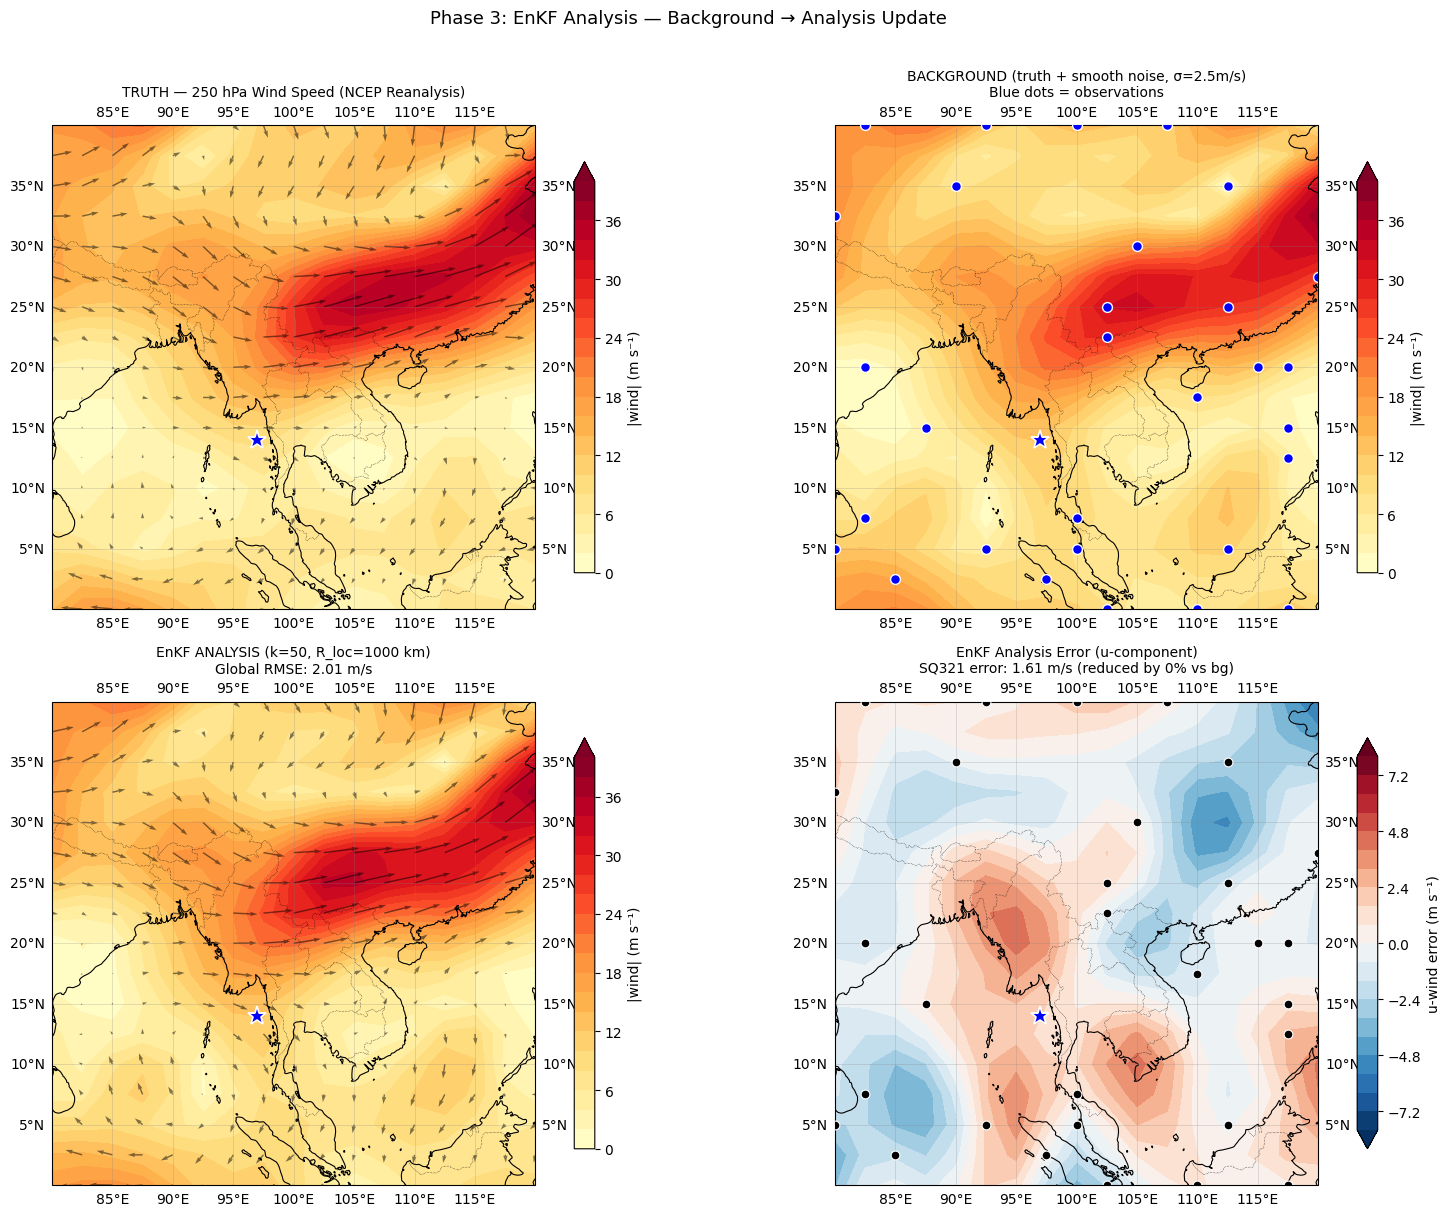

Saved fig07_enkf_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()
map_kw = dict(transform=ccrs.PlateCarree())
spd_lvls = np.linspace(0, 40, 21)
err_max  = 8.0
err_lvls = np.linspace(-err_max, err_max, 21)

def add_map_features(ax):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
    ax.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())
    ax.plot(SQ321_LON, SQ321_LAT, '*', ms=14, color='blue',
            markeredgecolor='white', markeredgewidth=1.2, **map_kw, zorder=6)

for ax in axes:
    add_map_features(ax)

# ── top-left: truth wind speed ────────────────────────────────────────────────
cf0 = axes[0].contourf(LON2D, LAT2D, np.sqrt(u250**2 + v250**2),
                        levels=spd_lvls, cmap='YlOrRd', extend='max', **map_kw)
plt.colorbar(cf0, ax=axes[0], label='|wind| (m s⁻¹)', shrink=0.85)
axes[0].quiver(LON2D, LAT2D, u250, v250, scale=400, width=0.003,
               color='k', alpha=0.5, **map_kw)
axes[0].set_title('TRUTH — 250 hPa Wind Speed (NCEP Reanalysis)', fontsize=10)

# ── top-right: background wind speed ─────────────────────────────────────────
u_bg = x_background[:N_grid].reshape(nlat, nlon)
v_bg = x_background[N_grid:].reshape(nlat, nlon)
cf1 = axes[1].contourf(LON2D, LAT2D, np.sqrt(u_bg**2 + v_bg**2),
                        levels=spd_lvls, cmap='YlOrRd', extend='max', **map_kw)
plt.colorbar(cf1, ax=axes[1], label='|wind| (m s⁻¹)', shrink=0.85)
axes[1].scatter(obs_lon, obs_lat, s=50, c='blue', edgecolors='white',
                lw=1, **map_kw, zorder=5)
axes[1].set_title(f'BACKGROUND (truth + smooth noise, σ={sigma_bg}m/s)\nBlue dots = observations', fontsize=10)

# ── bottom-left: EnKF analysis wind speed ────────────────────────────────────
cf2 = axes[2].contourf(LON2D, LAT2D, np.sqrt(u_enkf**2 + v_enkf**2),
                        levels=spd_lvls, cmap='YlOrRd', extend='max', **map_kw)
plt.colorbar(cf2, ax=axes[2], label='|wind| (m s⁻¹)', shrink=0.85)
axes[2].quiver(LON2D, LAT2D, u_enkf, v_enkf, scale=400, width=0.003,
               color='k', alpha=0.5, **map_kw)
axes[2].set_title(f'EnKF ANALYSIS (k={K_ENS}, R_loc={R_loc:.0f} km)\nGlobal RMSE: {rmse_enkf:.2f} m/s', fontsize=10)

# ── bottom-right: EnKF analysis error ────────────────────────────────────────
err_enkf_2d = (x_enkf[:N_grid] - x_truth[:N_grid]).reshape(nlat, nlon)
cf3 = axes[3].contourf(LON2D, LAT2D, err_enkf_2d,
                        levels=err_lvls, cmap='RdBu_r', extend='both', **map_kw)
plt.colorbar(cf3, ax=axes[3], label='u-wind error (m s⁻¹)', shrink=0.85)
axes[3].scatter(obs_lon, obs_lat, s=40, c='black', marker='o',
                edgecolors='white', lw=0.8, **map_kw, zorder=5, label='obs')
axes[3].set_title(f'EnKF Analysis Error (u-component)\nSQ321 error: {err_enkf_sq:.2f} m/s '
                  f'({"reduced" if recovery_enkf>0 else "increased"} by '
                  f'{abs(recovery_enkf)*100:.0f}% vs bg)', fontsize=10)

plt.suptitle('Phase 3: EnKF Analysis — Background → Analysis Update', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig07_enkf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig07_enkf_analysis.png')

## 6. Kalman Gain Map — Information Propagation

The Kalman gain column for a single observation shows **how far that observation's information reaches**. With EnKF + Gaspari-Cohn localization, the gain is hard-zeroed beyond R_loc. We plot the gain for the observation nearest to SQ321 — the only one that can theoretically inform the analysis there.

In [8]:
# index of the observation nearest to SQ321
nearest_obs_k = np.argmin(D[obs_idx, sq_grid_idx])
nearest_obs_dist = D[obs_idx[nearest_obs_k], sq_grid_idx]
nearest_obs_lat  = obs_lat[nearest_obs_k]
nearest_obs_lon  = obs_lon[nearest_obs_k]

print(f'Nearest observation to SQ321:')
print(f'  Location  : {nearest_obs_lat:.1f}°N, {nearest_obs_lon:.1f}°E')
print(f'  Distance  : {nearest_obs_dist:.0f} km from SQ321')
print(f'  Within R_loc ({R_loc:.0f} km): {nearest_obs_dist <= R_loc}')
print()

# u-observation index in H (first K_obs rows are u-obs)
near_obs_u_hidx = nearest_obs_k   # row of H for u at nearest obs
gain_col_enkf = K_ens[:N_grid, near_obs_u_hidx]   # Kalman gain for this obs → all u-points
gain_2d_enkf  = gain_col_enkf.reshape(nlat, nlon)

gain_sq321_enkf = gain_col_enkf[sq_grid_idx]
print(f'Kalman gain at SQ321 from nearest obs (u→u): {gain_sq321_enkf:.6f}')
print(f'  → A 1 m/s obs innovation here shifts SQ321 u-analysis by {gain_sq321_enkf:.6f} m/s')
print(f'  (MPDOK gain will be computed in Phase 4 for comparison)')

Nearest observation to SQ321:
  Location  : 7.5°N, 100.0°E
  Distance  : 877 km from SQ321
  Within R_loc (1000 km): True

Kalman gain at SQ321 from nearest obs (u→u): 0.000501
  → A 1 m/s obs innovation here shifts SQ321 u-analysis by 0.000501 m/s
  (MPDOK gain will be computed in Phase 4 for comparison)


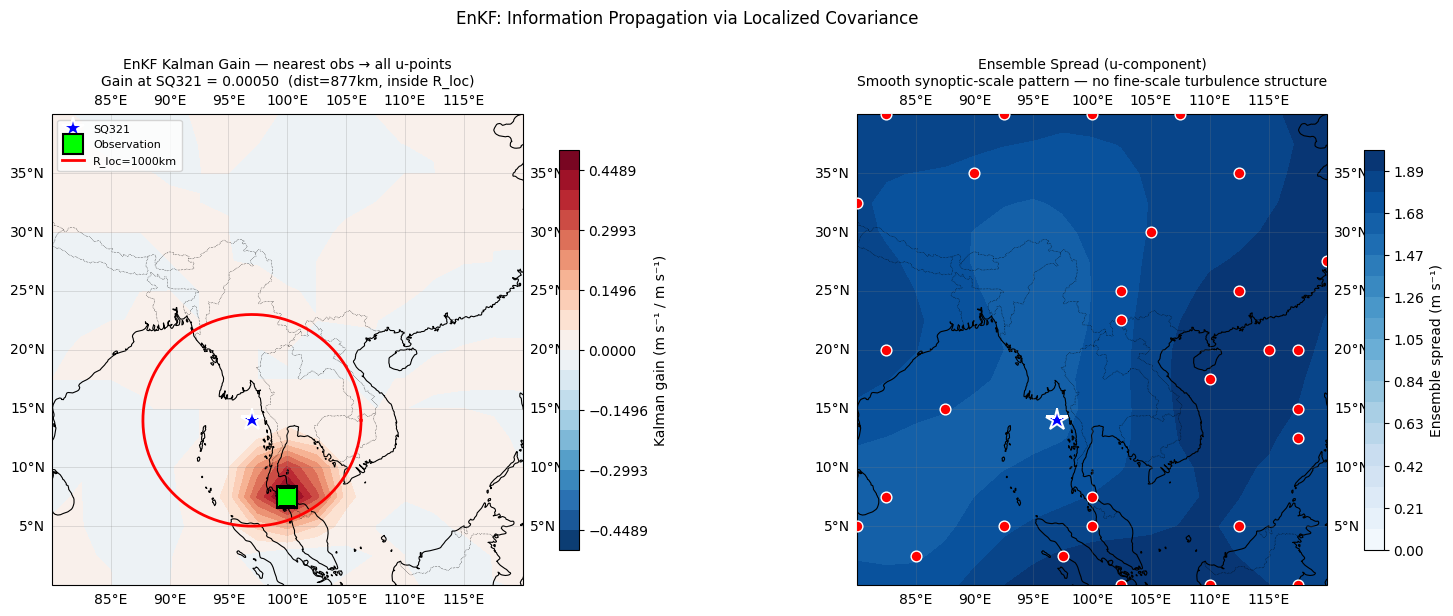

Saved fig08_enkf_gain.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})
map_kw = dict(transform=ccrs.PlateCarree())

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
    ax.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())
    ax.plot(SQ321_LON, SQ321_LAT, '*', ms=16, color='blue',
            markeredgecolor='white', markeredgewidth=1.5, **map_kw, zorder=7,
            label='SQ321')

# ── left: EnKF Kalman gain map ────────────────────────────────────────────────
vmax_gain = np.abs(gain_2d_enkf).max()
cf1 = axes[0].contourf(LON2D, LAT2D, gain_2d_enkf,
                        levels=np.linspace(-vmax_gain, vmax_gain, 21),
                        cmap='RdBu_r', **map_kw)
plt.colorbar(cf1, ax=axes[0], label='Kalman gain (m s⁻¹ / m s⁻¹)', shrink=0.85)

# observation location and localization circle
axes[0].plot(nearest_obs_lon, nearest_obs_lat, 's', ms=14,
             color='lime', markeredgecolor='k', markeredgewidth=1.5,
             **map_kw, zorder=6, label='Observation')

theta = np.linspace(0, 2*np.pi, 360)
dlon_c = R_loc / (6371 * np.cos(np.radians(SQ321_LAT))) * (180/np.pi)
dlat_c = R_loc / 6371 * (180/np.pi)
axes[0].plot(SQ321_LON + dlon_c*np.cos(theta),
             SQ321_LAT + dlat_c*np.sin(theta),
             'r-', lw=2, **map_kw, zorder=5, label=f'R_loc={R_loc:.0f}km')

axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title(f'EnKF Kalman Gain — nearest obs → all u-points\n'
                  f'Gain at SQ321 = {gain_sq321_enkf:.5f}  '
                  f'(dist={nearest_obs_dist:.0f}km, {"inside" if nearest_obs_dist<=R_loc else "outside"} R_loc)',
                  fontsize=10)

# ── right: ensemble spread map ────────────────────────────────────────────────
ens_spread_2d = X_ens[:N_grid, :].std(axis=1).reshape(nlat, nlon)
cf2 = axes[1].contourf(LON2D, LAT2D, ens_spread_2d,
                        levels=np.linspace(0, ens_spread_2d.max(), 20),
                        cmap='Blues', **map_kw)
plt.colorbar(cf2, ax=axes[1], label='Ensemble spread (m s⁻¹)', shrink=0.85)
axes[1].scatter(obs_lon, obs_lat, s=60, c='red', edgecolors='white',
                lw=1, **map_kw, zorder=5)
axes[1].set_title('Ensemble Spread (u-component)\n'
                  'Smooth synoptic-scale pattern — no fine-scale turbulence structure', fontsize=10)

plt.suptitle('EnKF: Information Propagation via Localized Covariance', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig08_enkf_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig08_enkf_gain.png')

## 7. Save EnKF Outputs

In [10]:
np.savez('phase3_enkf.npz',
         x_enkf=x_enkf,
         P_ens=P_ens,
         P_loc=P_loc,
         K_ens=K_ens,
         eigs_ens=eigs_ens,
         gain_2d_enkf=gain_2d_enkf,
         nearest_obs_k=np.int32(nearest_obs_k),
         nearest_obs_lat=np.float64(nearest_obs_lat),
         nearest_obs_lon=np.float64(nearest_obs_lon),
         nearest_obs_dist=np.float64(nearest_obs_dist),
         gain_sq321_enkf=np.float64(gain_sq321_enkf),
         rmse_bg=np.float64(rmse_bg),
         rmse_enkf=np.float64(rmse_enkf),
         err_bg_sq=np.float64(err_bg_sq),
         err_enkf_sq=np.float64(err_enkf_sq),
         err_bg_ti=np.float64(err_bg_ti),
         err_enkf_ti=np.float64(err_enkf_ti),
         K_ENS=np.int32(K_ENS))

print('Saved phase3_enkf.npz')
print()
print('=== Phase 3 Summary ===')
print(f'Ensemble size k      : {K_ENS}  (rank-{K_ENS-1} covariance)')
print(f'Localization R_loc   : {R_loc:.0f} km  (Gaspari-Cohn)')
print(f'Global RMSE          : {rmse_bg:.3f} → {rmse_enkf:.3f} m/s  ({(1-rmse_enkf/rmse_bg)*100:.1f}% improvement)')
print(f'SQ321 u-error        : {err_bg_sq:.3f} → {err_enkf_sq:.3f} m/s')
print(f'SQ321 recovery       : {recovery_enkf*100:.1f}%')
print(f'SQ321 Kalman gain    : {gain_sq321_enkf:.6f}  (from nearest obs at {nearest_obs_dist:.0f} km)')
print()
print('→ Phase 4 will apply MPDOK full Matérn kernel to the same problem.')
print('  All 30 observations inform every grid point — including SQ321.')

Saved phase3_enkf.npz

=== Phase 3 Summary ===
Ensemble size k      : 50  (rank-49 covariance)
Localization R_loc   : 1000 km  (Gaspari-Cohn)
Global RMSE          : 2.404 → 2.009 m/s  (16.4% improvement)
SQ321 u-error        : 1.607 → 1.606 m/s
SQ321 recovery       : 0.1%
SQ321 Kalman gain    : 0.000501  (from nearest obs at 877 km)

→ Phase 4 will apply MPDOK full Matérn kernel to the same problem.
  All 30 observations inform every grid point — including SQ321.
